# BII per-pixel trend

Per-pixel linear trend (OLS slope, Δ BII / yr) of the `data/mosaic_ovr64/bii_{year}_ovr64.tif` overview mosaics over the 2017-2025 timeseries. Pixels masked or NaN in any year are dropped.

In [2]:
import glob
import os
import re

import numpy as np
import rasterio as rio
from rasterio.plot import plotting_extent
import matplotlib.pyplot as plt

years = np.arange(2017, 2026)
files = [f'../data/mosaic_ovr64/bii_{year}_ovr64.tif' for year in years]

stack = np.ma.masked_invalid(np.ma.stack([rio.open(f).read(1, masked=True) for f in files]))
with rio.open(files[0]) as s:
    extent = plotting_extent(s)
years

array([2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025])

In [3]:
# Per-pixel OLS slope; only pixels valid in every year are kept.
x = years - years.mean()
valid = ~stack.mask.any(axis=0)
y = stack.filled(0)
slope = np.ma.masked_array(
    (x[:, None, None] * (y - y.mean(axis=0))).sum(axis=0) / (x ** 2).sum(),
    mask=~valid,
)
print(f"mean trend: {slope.mean():+.5f} / yr   valid pixels: {valid.sum():,}")

mean trend: -0.00069 / yr   valid pixels: 4,743,636


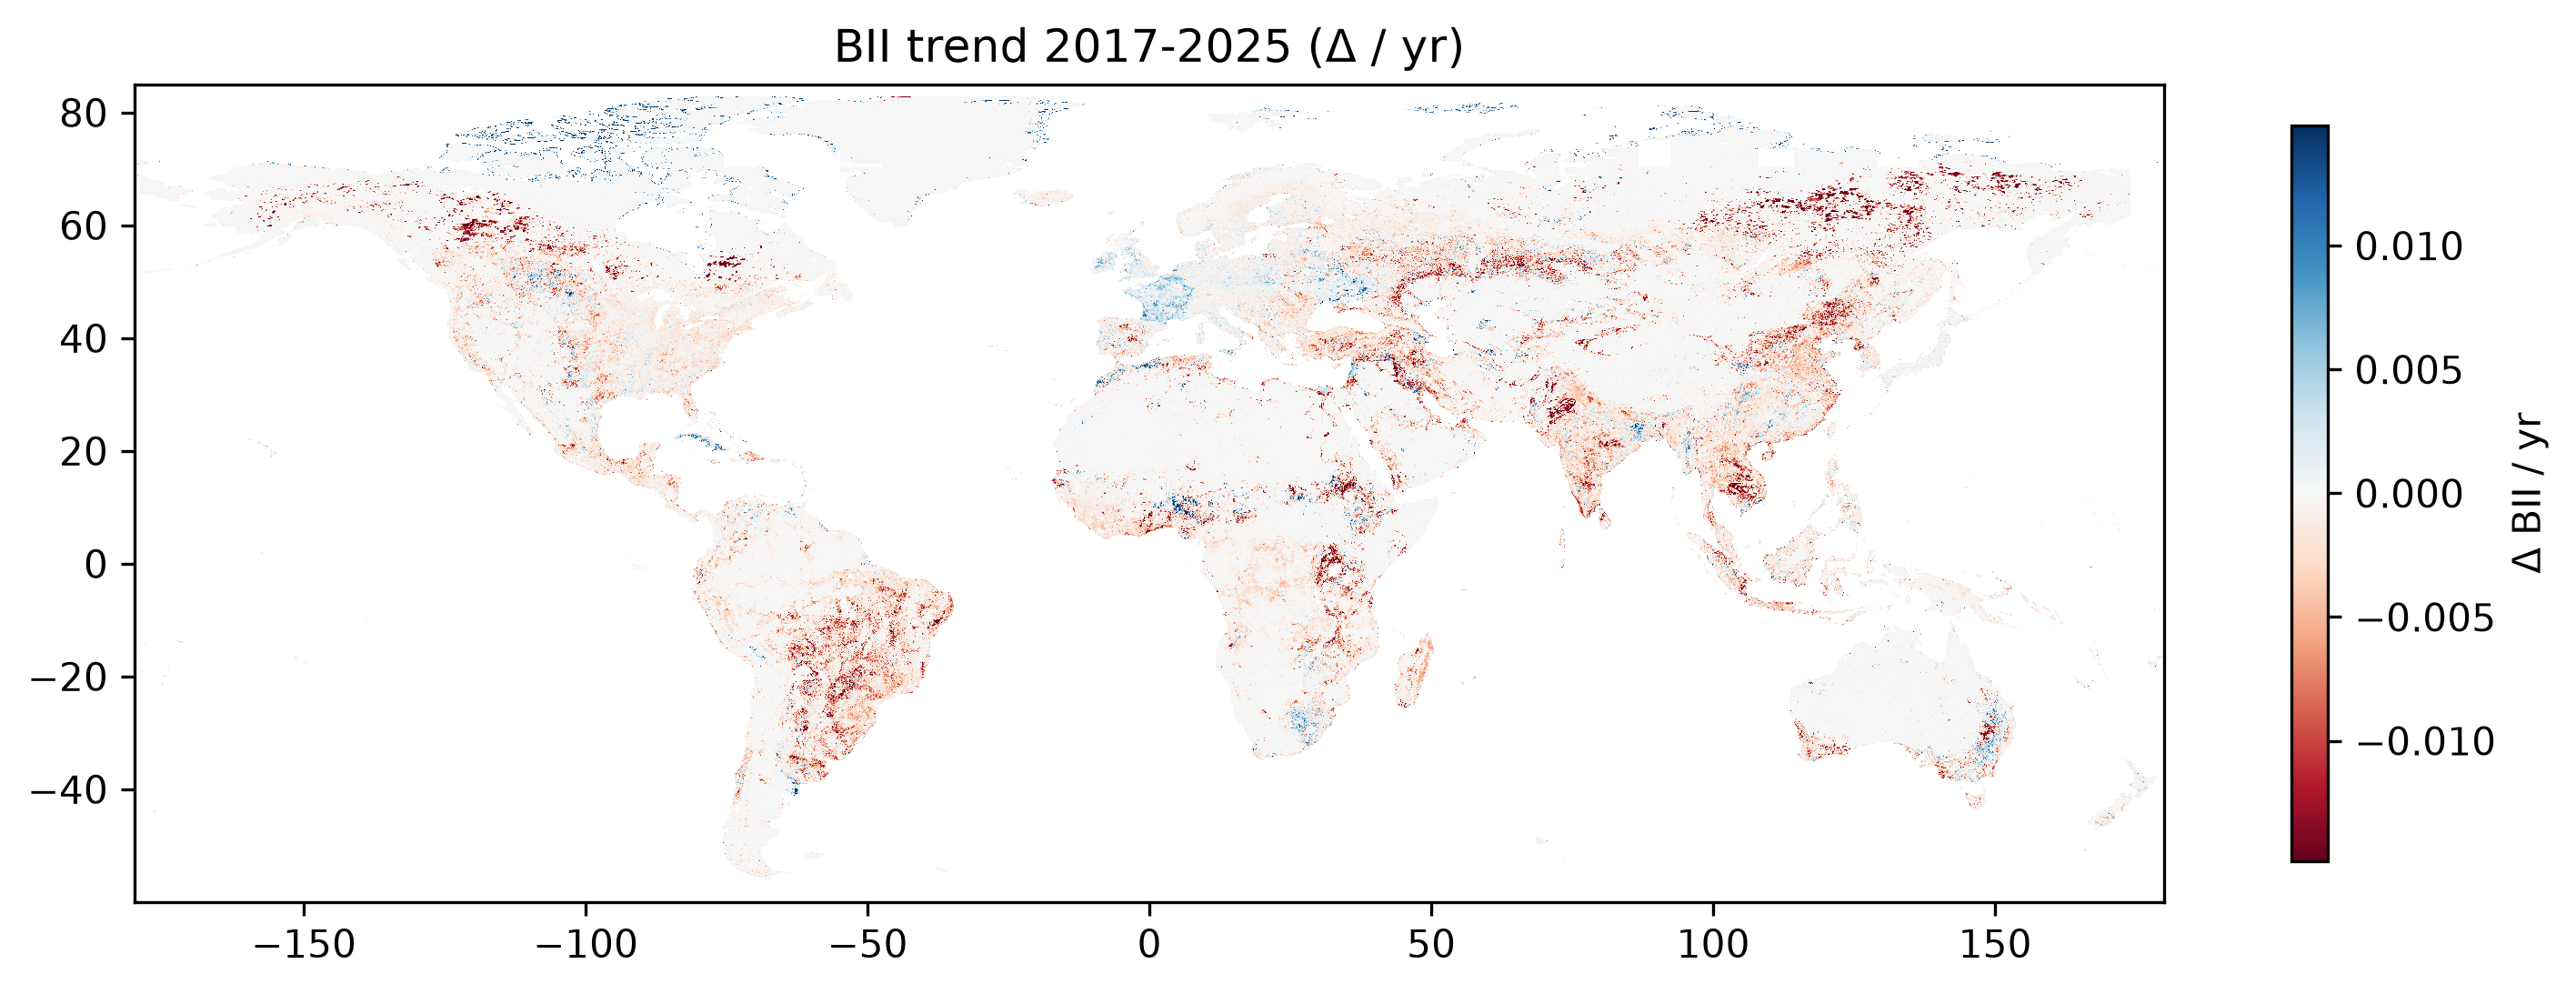

In [4]:
v = np.percentile(np.abs(slope.compressed()), 99)
fig, ax = plt.subplots(figsize=(12, 5), dpi=300)
im = ax.imshow(slope, extent=extent, cmap="RdBu", vmin=-v, vmax=v, interpolation="none")
ax.set_title(f"BII trend {years.min()}-{years.max()} (Δ / yr)")
fig.colorbar(im, ax=ax, shrink=0.7, label="Δ BII / yr")

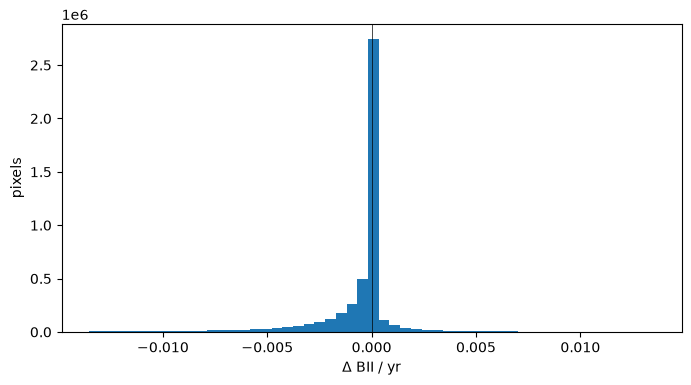

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(slope.compressed(), bins=200)
ax.axvline(0, color="k", lw=0.5)
ax.set(xlabel="Δ BII / yr", ylabel="pixels", xlim=(-v, v));

In [ ]:
# Export the slope raster as a GeoTIFF.
with rio.open(files[0]) as s:
    profile = s.profile
profile.update(dtype="float32", nodata=np.nan, compress="deflate")
with rio.open(os.path.join("..", "data", "mosaic_ovr64", "bii_trend_ovr64.tif"), "w", **profile) as dst:
    dst.write(slope.filled(np.nan).astype("float32"), 1)